# Radiology Data Quality Assessment Through the Five Facets Framework

**Assignment Part II — Data Quality Analysis**

In this assignment, you will:
1. Learn about the **Five Facets of Data Quality Assessment** framework
2. Explore a synthetic radiology event log with intentional quality issues
3. Work within the context of three research questions (RQs)
4. **Choose and run** DQ assessment methods from a provided toolkit
5. Analyse results through the lens of the five facets
6. Manually explore the data to identify additional quality dimensions
7. Reflect on the limitations of automated assessment and event logs

**Important notes:**
- You will write ~20-25% code (basic exploration, running analyses, creating visualisations)
- Focus is on **choosing appropriate methods**, **interpreting results**, and **critical analysis**
- **All numbered "Reflection Questions" should be answered in your main report (Deliverable 7), not in this notebook**
- There is no single "correct" set of methods — you must justify your choices
- In-notebook analyses are brief; deeper reflections go in your report

## Part 0: Understanding the Context

### Three Research Questions (RQs) Guiding This Assignment

Your DQ assessment will be contextualised by three hypothetical research questions:

**RQ1: Workflow Efficiency & Bottlenecks**  
*"What are the average turnaround times for different stages of the radiology workflow, and where do delays occur?"*
- **Task context**: Performance monitoring for department management
- **Human stakeholders**: Radiology managers, administrators

**RQ2: Quality of Care & Critical Finding Communication**  
*"How consistently are critical radiological findings communicated to ordering clinicians, and within what timeframes?"*
- **Task context**: Patient safety monitoring and regulatory compliance
- **Human stakeholders**: Radiologists, clinicians, patient safety officers

**RQ3: AI-Based Triage System Development**  
*"Can we develop an automated triage system to prioritise cases by urgency and complexity, routing them to appropriate radiologists?"*
- **Task context**: Clinical decision support and workflow optimisation
- **Human stakeholders**: Radiologists, AI developers, workflow coordinators

As you assess data quality, consider: **Which RQ(s) would be affected by the quality issues you find?**

## Part 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from IPython.display import display
import re

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

# Schema requirements (metadata)
REQUIRED_COLUMNS = [
    'case_id', 'accession_number', 'event_time', 'activity',
    'fhir_resource', 'actor', 'role',
]

EXPECTED_ACTIVITIES = [
    'Order placed', 'Order accepted', 'Patient selected from worklist',
    'Image acquisition start', 'Image acquisition end', 'Images uploaded to PACS',
    'Case selected', 'Preliminary report created', 'Report validated and approved',
    'Report finalised', 'Report distributed', 'Critical communication',
]

def resolve_log_file(filename: str = 'radiology_event_log.csv') -> Path:
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path('/Users/christiankristensen/Downloads/assignment-2-afleveringsopgaver-1-main/2025-2026/assignment2/code') / filename,
        Path('/Users/christiankristensen/Assignment 2/afleveringsfiler') / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'Could not find {filename}. Checked: {candidates}')

LOG_FILE = resolve_log_file()


In [2]:
def load_event_log(filepath: Path) -> pd.DataFrame:
    """
    Load CSV and parse event_time as datetime.
    """
    df = pd.read_csv(filepath)
    df['event_time'] = pd.to_datetime(df['event_time'])
    return df

# Load the data
df = load_event_log(LOG_FILE)
print(f'Loaded {len(df)} events across {df["case_id"].nunique()} cases')
print(f'Time range: {df["event_time"].min()} to {df["event_time"].max()}')
print(f'Using file: {LOG_FILE}')
display(df.head())


Loaded 150 events across 17 cases
Time range: 2026-01-12 07:45:00 to 2026-01-13 08:46:00
Using file: radiology_event_log.csv


,case_id,accession_number,event_time,activity,fhir_resource,actor,role,modality,study_uid,series_count,instance_count,report_id,icd11_code,notes
0,TEST-001,TEST001,2026-01-12 07:45:00,Order placed,ServiceRequest,Admin User,system,NaN,NaN,NaN,NaN,NaN,NaN,indication=TRAINING CASE - DO NOT PROCESS
1,CXR-001,ACC20260112001,2026-01-12 08:14:00,Order placed,ServiceRequest,Dr. Jensen,clinician,NaN,NaN,NaN,NaN,NaN,NaN,indication=Suspected pneumonia
2,CXR-001,ACC20260112001,2026-01-12 08:16:00,Order accepted,Task,RIS System,system,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CXR-002,ACC20260112002,2026-01-12 08:22:00,Order placed,ServiceRequest,Dr. Patel,clinician,NaN,NaN,NaN,NaN,NaN,NaN,indication=Central line position check
4,CXR-002,ACC20260112002,2026-01-12 08:24:00,Order accepted,Task,RIS System,system,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.1 Initial Data Exploration

Before running formal DQ assessments, explore the data manually. Look at data types, columns, distributions, etc. You can also have a look at the .csv file. This corresponds to the **Data Facet** — understanding what data you have.

=== 1) Data types and column overview ===


,dtype,non_null_count,missing_count,missing_pct
study_uid,str,16,134,89.33
series_count,float64,16,134,89.33
instance_count,float64,16,134,89.33
icd11_code,str,19,131,87.33
report_id,str,37,113,75.33
modality,str,49,101,67.33
notes,str,77,73,48.67
case_id,str,150,0,0.00
accession_number,str,150,0,0.00
event_time,datetime64[us],150,0,0.00



=== 2) Unique values in key columns ===
- activity: 12 unique values
  ['Case selected', 'Critical communication', 'Image acquisition end', 'Image acquisition start', 'Images uploaded to PACS', 'Order accepted', 'Order placed', 'Patient selected from worklist', 'Preliminary report created', 'Report distributed', 'Report finalised', 'Report validated and approved']
- role: 5 unique values
  ['clinician', 'radiographer', 'resident', 'senior', 'system']
- fhir_resource: 4 unique values
  ['DiagnosticReport', 'ImagingStudy', 'ServiceRequest', 'Task']
- modality: 2 unique values
  ['CR', 'DX']

=== 3) Missing values by column ===


,missing_count,missing_pct
study_uid,134,89.33
series_count,134,89.33
instance_count,134,89.33
icd11_code,131,87.33
report_id,113,75.33
modality,101,67.33
notes,73,48.67


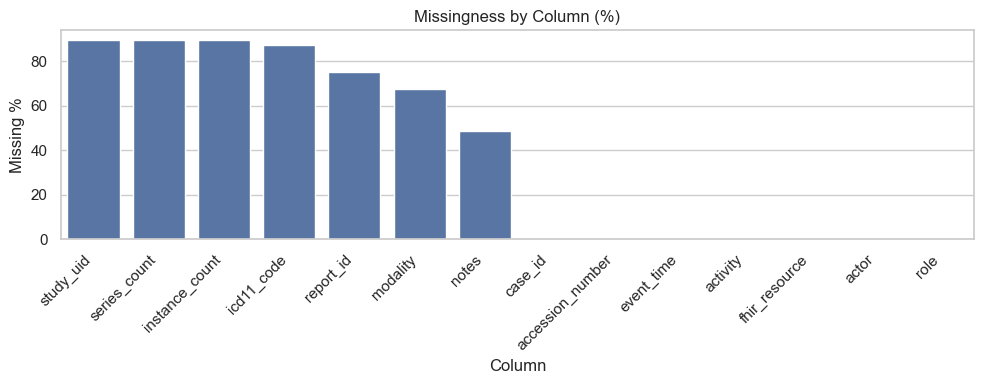

=== 4) Events per case distribution ===


,event_count
case_id,
CXR-013,13
CXR-003,11
CXR-010,10
CXR-004,10
CXR-016,10
CXR-007,10
CXR-001,9
CXR-014,9
CXR-012,9


,count,mean,std,min,25%,50%,75%,max
value,17.0,8.823529,2.4299,1.0,8.0,9.0,10.0,13.0


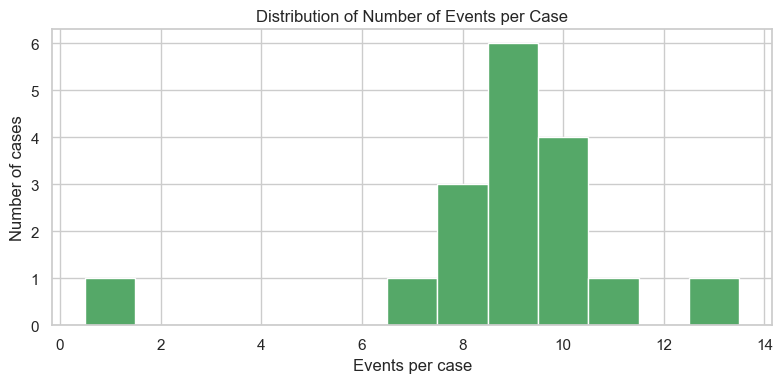

=== 5) Time span covered by the log ===
Start: 2026-01-12 07:45:00
End:   2026-01-13 08:46:00
Duration: 25.02 hours


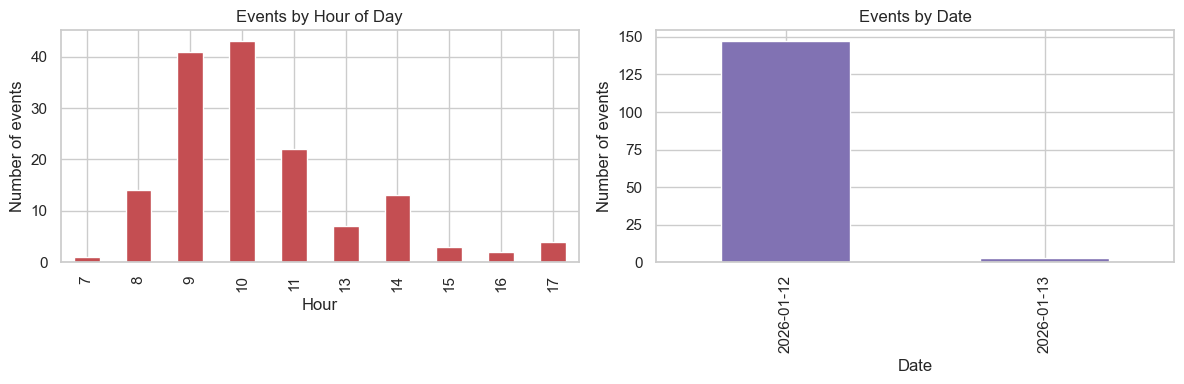

In [3]:
# Part 1 exploration

print('=== 1) Data types and column overview ===')
overview_df = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null_count': df.notna().sum(),
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
}).sort_values('missing_count', ascending=False)
display(overview_df)

print('\n=== 2) Unique values in key columns ===')
for col in ['activity', 'role', 'fhir_resource', 'modality']:
    unique_values = sorted(df[col].dropna().unique().tolist())
    print(f'- {col}: {len(unique_values)} unique values')
    print(f'  {unique_values}')

print('\n=== 3) Missing values by column ===')
missing_summary = df.isna().sum().sort_values(ascending=False).to_frame('missing_count')
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(df) * 100).round(2)
display(missing_summary[missing_summary['missing_count'] > 0])

plt.figure(figsize=(10, 4))
plot_df = missing_summary.reset_index().rename(columns={'index': 'column'})
sns.barplot(data=plot_df, x='column', y='missing_pct', color='#4C72B0')
plt.title('Missingness by Column (%)')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('=== 4) Events per case distribution ===')
events_per_case = df.groupby('case_id').size().sort_values(ascending=False).rename('event_count')
display(events_per_case.to_frame())
display(events_per_case.describe().to_frame('value').T)

plt.figure(figsize=(8, 4))
bins = np.arange(events_per_case.min(), events_per_case.max() + 2) - 0.5
plt.hist(events_per_case.values, bins=bins, color='#55A868', edgecolor='white')
plt.title('Distribution of Number of Events per Case')
plt.xlabel('Events per case')
plt.ylabel('Number of cases')
plt.tight_layout()
plt.show()

print('=== 5) Time span covered by the log ===')
start_time = df['event_time'].min()
end_time = df['event_time'].max()
duration_hours = (end_time - start_time).total_seconds() / 3600
print(f'Start: {start_time}')
print(f'End:   {end_time}')
print(f'Duration: {duration_hours:.2f} hours')

events_by_hour = df.assign(hour=df['event_time'].dt.hour).groupby('hour').size().rename('events')
events_by_date = df.assign(date=df['event_time'].dt.date).groupby('date').size().rename('events')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
events_by_hour.plot(kind='bar', ax=axes[0], color='#C44E52')
axes[0].set_title('Events by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of events')

events_by_date.plot(kind='bar', ax=axes[1], color='#8172B3')
axes[1].set_title('Events by Date')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of events')

plt.tight_layout()
plt.show()



**→ Reflection Question 1** (answer in your main report):  
What kind of data is logged in the file? Assuming data quality is good, how can the data be used to answer the RQs? 

## Part 2: The DQ Assessment Toolkit

Below are **pre-implemented** functions for assessing various DQ dimensions. 

**Your task**: 
1. Review all available methods
2. **Choose 4-5 methods** to run (you don't need to run all of them)
3. Consider which methods are most relevant to the RQs
4. Run the methods and analyse results
5. Justify your choices

### 2.1 Available DQ Assessment Methods

#### **Method 1: Schema Validation**
- **DQ Dimension**: Completeness (schema-level)
- **Description**: Checks if required columns exist, if event_time is valid, if activities are known

In [4]:
def method_1_schema_validation(df: pd.DataFrame) -> Dict[str, bool]:
    """
    Validate schema-level completeness.
    Checks against schema requirements (metadata)
    Reflects how the system enforces data structure
    """
    results = {
        'columns_present': all(col in df.columns for col in REQUIRED_COLUMNS),
        'datetime_valid': df['event_time'].notna().all(),
        'activities_known': df['activity'].isin(EXPECTED_ACTIVITIES).all()
    }
    return results

#### **Method 2: Completeness — Missing Values Analysis**
- **DQ Dimension**: Completeness (attribute-level)
- **Description**: Identifies missing values, including hidden placeholders

In [5]:
def method_2_completeness_missing_values(df: pd.DataFrame) -> Dict[str, any]:
    """
    Assess completeness by identifying missing and hidden missing values.
    Detects NaN, empty strings, and potential placeholders
    Finds missing values may indicate collection process issues
    """
    results = {
        'missing_counts': df.isnull().sum().to_dict(),
        'empty_strings': {col: (df[col] == '').sum() for col in df.select_dtypes(include='object').columns},
        'potential_placeholders': {}
    }
    
    # Check for common placeholder values
    for col in df.select_dtypes(include='object').columns:
        placeholders = df[col].isin(['N/A', 'n/a', 'NA', 'Unknown', 'UNKNOWN', '-', '--', '99', '-99']).sum()
        if placeholders > 0:
            results['potential_placeholders'][col] = placeholders
    
    return results

#### **Method 3: Accuracy — ICD-11 Code Validation**
- **DQ Dimension**: Accuracy (syntactic correctness)
- **Description**: Validates ICD-11 code format and placement

In [6]:
def method_3_accuracy_icd11_validation(df: pd.DataFrame) -> Dict[str, any]:
    """
    Validate ICD-11 codes for format and context accuracy.
    Checks code format against ICD-11 standard (reference data)
    Informs system's data entry validation
    """
    results = {
        'codes_in_wrong_activity': [],
        'invalid_format_codes': [],
        'free_text_in_code_field': []
    }
    
    if 'icd11_code' not in df.columns:
        return results
    
    # ICD-11 format: 2 uppercase letters + numbers + optional dot + numbers
    icd11_pattern = re.compile(r'^[A-Z]{2}[0-9]+(\.[0-9]+)?$')
    
    for idx, row in df.iterrows():
        code = row.get('icd11_code', '')
        if pd.isna(code) or code == '':
            continue
            
        # Check if code appears in wrong activity
        if code and row['activity'] != 'Report finalised':
            results['codes_in_wrong_activity'].append((row['case_id'], row['activity'], code))
        
        # Check format validity
        if code and not icd11_pattern.match(str(code)):
            # Distinguish between format errors and free text
            if len(str(code).split()) > 1 or not any(c.isdigit() for c in str(code)):
                results['free_text_in_code_field'].append((row['case_id'], code))
            else:
                results['invalid_format_codes'].append((row['case_id'], code))
    
    return results

#### **Method 4: Representativity — Actors, Roles, and Workforce Equity**
- **DQ Dimension**: Representativity
- **Description**: Assesses whether all expected actors/roles are represented and whether workload is distributed equitably

In [7]:
def method_4_representativity_actors_equity(df: pd.DataFrame) -> Dict[str, any]:
    """
    Assess representativity of actors and roles in the log, including equity analysis.
    
    Analyses:
    - Distribution of actor/role attributes 
    - Whether data represents expected workflow participants
    - Different human roles have different patterns
    - Workload distribution equity across staff
    - Gender balance if available
    - Role representation completeness
    """
    results = {
        'unique_actors': df['actor'].nunique(),
        'unique_roles': df['role'].nunique(),
        'actor_distribution': df['actor'].value_counts().to_dict(),
        'role_distribution': df['role'].value_counts().to_dict(),
        'activities_per_role': df.groupby('role')['activity'].unique().to_dict()
    }
    
    # Workload equity analysis
    cases_per_actor = df.groupby('actor')['case_id'].nunique()
    if len(cases_per_actor) > 0:
        results['workload_equity'] = {
            'mean_cases_per_actor': cases_per_actor.mean(),
            'std_cases_per_actor': cases_per_actor.std(),
            'min_cases': cases_per_actor.min(),
            'max_cases': cases_per_actor.max(),
            'gini_coefficient': None  # Could calculate if needed for detailed equity analysis
        }
        
        # Identify potential equity issues (extreme outliers)
        q1 = cases_per_actor.quantile(0.25)
        q3 = cases_per_actor.quantile(0.75)
        iqr = q3 - q1
        overloaded = cases_per_actor[cases_per_actor > q3 + 1.5 * iqr]
        underloaded = cases_per_actor[cases_per_actor < q1 - 1.5 * iqr]
        
        results['workload_outliers'] = {
            'overloaded_actors': overloaded.to_dict(),
            'underloaded_actors': underloaded.to_dict()
        }
    
    # Role completeness: Are all expected clinical roles present?
    expected_roles = ['Radiographer', 'Radiologist', 'Resident', 'Clerk']  # Adjust based on context
    present_roles = set(df['role'].dropna().unique())
    results['role_completeness'] = {
        'expected_roles': expected_roles,
        'present_roles': list(present_roles),
        'missing_roles': list(set(expected_roles) - present_roles)
    }
    
    return results

#### **Method 5: Representativity — Case Mix by Modality**
- **DQ Dimension**: Representativity
- **Description**: Assesses whether different imaging modalities are adequately represented

In [8]:
def method_5_representativity_modality(df: pd.DataFrame) -> Dict[str, any]:
    """
    Assess representativity of imaging modalities.
    Distribution of modality values
    Different modalities represent different case types/complexity and have different data requirements. E.g., mobile X-ray (DX) has to have a location note.
    """
    # Get modality from upload events
    upload_events = df[df['activity'] == 'Images uploaded to PACS'].copy()
    
    if 'modality' not in upload_events.columns:
        return {'error': 'Modality column not found'}
    
    results = {
        'total_cases': upload_events['case_id'].nunique(),
        'modality_distribution': upload_events['modality'].value_counts().to_dict(),
        'modality_percentages': (upload_events['modality'].value_counts(normalize=True) * 100).to_dict(),
        'missing_modality': upload_events['modality'].isna().sum()
    }
    return results

#### **Method 6: Representativity — Case Characteristics, Equipment, and Patient Demographics**
- **DQ Dimension**: Representativity
- **Description**: Assesses representativity across case urgency, anatomical regions, patient demographics, and equipment usage

In [9]:
def method_6_representativity_comprehensive(df: pd.DataFrame) -> Dict[str, any]:
    """
    Assess comprehensive representativity across multiple dimensions:
    - Case urgency levels (routine, urgent, stat)
    - Anatomical regions/body parts examined
    - Time of day / shift patterns
    - Equipment usage (if logged)
    - Patient demographics (age groups, if available)
    
    This informs:
    - Whether training data for AI (RQ3) represents all case types
    - Whether performance metrics (RQ1) cover all scenarios
    - Ethical considerations: are certain patient groups under-represented?
    """
    results = {}
    
    # Urgency/Priority analysis from notes or case attributes
    if 'notes' in df.columns:
        # Extract urgency markers
        df_temp = df.copy()
        df_temp['has_stat'] = df_temp['notes'].astype(str).str.contains('stat|STAT|urgent|URGENT', case=False, na=False)
        df_temp['has_routine'] = df_temp['notes'].astype(str).str.contains('routine|ROUTINE', case=False, na=False)
        
        urgency_cases = df_temp.groupby('case_id').agg({
            'has_stat': 'any',
            'has_routine': 'any'
        })
        
        results['urgency_distribution'] = {
            'stat_urgent_cases': urgency_cases['has_stat'].sum(),
            'routine_cases': urgency_cases['has_routine'].sum(),
            'unspecified': len(urgency_cases) - urgency_cases['has_stat'].sum() - urgency_cases['has_routine'].sum(),
            'total_cases': len(urgency_cases)
        }
    
    # Anatomical region analysis (if body_part column exists)
    if 'body_part' in df.columns:
        body_part_dist = df[df['activity'] == 'Images uploaded to PACS']['body_part'].value_counts()
        results['anatomical_distribution'] = body_part_dist.to_dict()
        results['anatomical_coverage'] = {
            'unique_body_parts': len(body_part_dist),
            'missing_body_part': df[df['activity'] == 'Images uploaded to PACS']['body_part'].isna().sum()
        }
    
    # Temporal representativity: Are all shifts/times of day represented?
    df_temp = df.copy()
    df_temp['hour'] = df_temp['event_time'].dt.hour
    df_temp['shift'] = pd.cut(df_temp['hour'], bins=[0, 8, 16, 24], labels=['Night', 'Day', 'Evening'], include_lowest=True)
    
    shift_cases = df_temp.groupby('case_id')['shift'].first().value_counts()
    results['temporal_distribution'] = {
        'cases_by_shift': shift_cases.to_dict(),
        'shift_balance': shift_cases.to_dict()
    }
    
    # Equipment diversity (if station_name or device_id available)
    if 'station_name' in df.columns:
        equipment_usage = df[df['activity'].str.contains('acquisition', case=False, na=False)]['station_name'].value_counts()
        results['equipment_usage'] = {
            'unique_stations': len(equipment_usage),
            'distribution': equipment_usage.to_dict(),
            'concentration': equipment_usage.max() / equipment_usage.sum() if len(equipment_usage) > 0 else 0
        }
    
    # Patient demographics (if available - age, gender)
    # Note: Often not in event logs due to privacy, but important for ethics analysis
    if 'patient_age' in df.columns:
        ages = df.groupby('case_id')['patient_age'].first().dropna()
        results['age_distribution'] = {
            'mean_age': ages.mean(),
            'age_groups': pd.cut(ages, bins=[0, 18, 45, 65, 100], labels=['Pediatric', 'Adult', 'Middle-aged', 'Elderly']).value_counts().to_dict()
        }
    
    # Ethical consideration: Data concentration

    results['ethical_notes'] = {    

        'comment': 'Check if certain patient groups, times, or case types are systematically under-represented. This affects fairness of AI systems and generalisability of performance metrics.'    
    }
    return results

#### **Method 7: Conformance Check — Temporal Sequence**
- **DQ Dimension**: Consistency (workflow conformance)
- **Description**: Verifies activities occur in expected order with plausible timing

In [10]:
def method_7_conformance_temporal_sequence(df: pd.DataFrame) -> pd.DataFrame:
    """
    Temporal sequence conformance.

    Full workflow temporal sequence with optional resident path:
        Order placed < Order accepted < Patient selected from worklist < Image acquisition start 
        < Image acquisition end < Images uploaded to PACS < Case selected
        < [Optional for resident cases: Preliminary report created < Report validated and approved]
        < Report finalised < Report distributed

    Timestamp ordering and values
    Expected workflow sequence (fitness for clinical process)
    Whether logging accurately captured event order
    
    This method specifically helps identify BATCH LOGGING issues:
    - Multiple events at identical timestamps
    - All events clustered within very short timeframe (e.g., < 1 minute for entire case)
    - Events recorded at suspicious times (e.g., all at 17:00 - end of shift)
    """
    required_sequence = [
        'Order placed', 'Order accepted', 'Patient selected from worklist',
        'Image acquisition start', 'Image acquisition end', 'Images uploaded to PACS',
        'Case selected', 'Report finalised', 'Report distributed'
    ]
    
    results = []
    
    for case_id, case_df in df.groupby('case_id'):
        case_df = case_df.sort_values('event_time')
        violations = []
        
        # Check all required activities exist
        missing = set(required_sequence) - set(case_df['activity'].values)
        if missing:
            violations.append(f"Missing activities: {', '.join(missing)}")
        
        # Check sequence order
        activity_times = {}
        for activity in required_sequence:
            rows = case_df[case_df['activity'] == activity]
            if len(rows) > 0:
                activity_times[activity] = rows['event_time'].iloc[0]
        
        for i in range(len(required_sequence) - 1):
            curr = required_sequence[i]
            next_act = required_sequence[i + 1]
            if curr in activity_times and next_act in activity_times:
                if activity_times[curr] >= activity_times[next_act]:
                    violations.append(f"VIOLATION: {curr} >= {next_act}")
        
        # BATCH LOGGING DETECTION: Check for duplicate timestamps
        duplicates = case_df[case_df.duplicated('event_time', keep=False)]
        if len(duplicates) > 0:
            unique_dup_times = duplicates['event_time'].nunique()
            violations.append(f"WARNING - BATCH LOGGING: {len(duplicates)} events share {unique_dup_times} timestamp(s)")
        
        # BATCH LOGGING DETECTION: Check for suspiciously short case duration
        if len(case_df) > 3:  # Only check if case has multiple events
            case_duration = (case_df['event_time'].max() - case_df['event_time'].min()).total_seconds() / 60
            if case_duration < 1:  # All events within 1 minute
                violations.append(f"WARNING - BATCH LOGGING: All {len(case_df)} events within {case_duration:.2f} minutes (likely batch entry)")
        
        # BATCH LOGGING DETECTION: Check for end-of-shift logging pattern
        event_hours = case_df['event_time'].dt.hour.unique()
        event_minutes = case_df['event_time'].dt.minute.unique()
        if len(event_hours) == 1 and event_hours[0] in [17, 18, 8, 9]:  # Shift change times
            if len(event_minutes) <= 2:  # All events within 2 minute values
                violations.append(f"WARNING - BATCH LOGGING: All events at {event_hours[0]:02d}:xx (end-of-shift pattern)")
        
        # Check for implausible gaps
        if 'Image acquisition end' in activity_times and 'Images uploaded to PACS' in activity_times:
            gap = (activity_times['Images uploaded to PACS'] - activity_times['Image acquisition end']).total_seconds() / 60
            if gap > 120:  # More than 2 hours
                violations.append(f"WARNING: Suspicious gap between acquisition and upload: {gap:.0f} minutes")
        
        results.append({
            'case_id': case_id,
            'c1_passed': len(violations) == 0,
            'c1_violations': '; '.join(violations) if violations else 'None'
        })
    
    return pd.DataFrame(results)

#### **Method 8: Conformance Check — Critical Finding Communication**
- **DQ Dimension**: Timeliness (task-specific)
- **Description**: Ensures critical findings are communicated within acceptable timeframe
- **Important**: When using this method, you should specify the `threshold_minutes` parameter and reflect on your choice. The default of 15 minutes may not be appropriate for all contexts.

In [11]:
def method_8_conformance_critical_communication(df: pd.DataFrame, threshold_minutes: int = 15) -> pd.DataFrame:
    """
    Critical findings should be communicated timely.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Event log dataframe
    threshold_minutes : int, default=15
        Maximum acceptable time (in minutes) between report finalisation and critical communication.

        
    Facet considerations:
    - Clinical requirement for urgent communication 
    - Timestamp accuracy and 'notes' field parsing 
    - What humans consider "critical" and "timely"
    """
    results = []
    
    for case_id, case_df in df.groupby('case_id'):
        # Check if case is marked as critical
        is_critical = case_df['notes'].astype(str).str.contains('critical=true', case=False, na=False).any()
        
        if not is_critical:
            results.append({
                'case_id': case_id,
                'c4_passed': True,
                'c4_detail': 'Not a critical case'
            })
            continue
        
        final_row = case_df[case_df['activity'] == 'Report finalised']
        comm_row = case_df[case_df['activity'] == 'Critical communication']
        
        if len(final_row) == 0:
            results.append({
                'case_id': case_id,
                'c4_passed': False,
                'c4_detail': 'Critical case missing Report finalised'
            })
            continue
        
        if len(comm_row) == 0:
            results.append({
                'case_id': case_id,
                'c4_passed': False,
                'c4_detail': 'Critical case missing Critical communication event'
            })

            continue
        
        final_time = final_row['event_time'].iloc[0]
        comm_time = comm_row['event_time'].iloc[0]
        gap_minutes = (comm_time - final_time).total_seconds() / 60
        
        passed = 0 <= gap_minutes <= threshold_minutes
        results.append({
            'case_id': case_id,
            'c4_passed': passed,
            'c4_detail': f"Communication gap: {gap_minutes:.1f} minutes (threshold: {threshold_minutes})"
        })
    
    return pd.DataFrame(results)

#### **Method 9: Conformance Check — Modality-Specific Attributes**
- **DQ Dimension**: Accuracy (semantic correctness)
- **Description**: Validates modality-specific data requirements based on DICOM standards and clinical protocols

These requirements reflect clinical imaging protocols and PACS data quality standards.

**Modality Requirements Explained:**

- **DX (Digital Radiography - Portable/Mobile X-ray)**: Must include patient location (e.g., ward, ICU, emergency) because equipment moves to patient. Location is critical for logistics and dose tracking.
- **MR (if implemented)**: Should include field strength, sequence type, contrast timing
- **CR (Computed Radiography)**: Must have minimum series count (≥2 for AP/lateral views) and instance count (≥4 images) to ensure complete diagnostic study. Single-view imaging is typically inadequate for diagnosis.
- **CT (if implemented)**: Should include slice thickness, contrast usage, reconstruction algorithm

In [12]:
def method_9_conformance_modality_attributes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Modality-specific attribute requirements.
    
    Validates that each imaging modality has its required metadata attributes:
    - DX (portable X-ray): location information required
    - CR (computed radiography): minimum series/instance counts for complete study
    
    Facet considerations:
    - Modality codes and required attributes (Data Facet)
    - PACS system should enforce these requirements (System Facet)
    - Different imaging tasks have different clinical data needs (Task Facet)
    """
    results = []
    
    for case_id, case_df in df.groupby('case_id'):
        upload_row = case_df[case_df['activity'] == 'Images uploaded to PACS']
        
        if len(upload_row) == 0:
            results.append({
                'case_id': case_id,
                'passed': False,
                'detail': 'No upload event found'
            })
            continue
        
        upload_row = upload_row.iloc[0]
        modality = upload_row.get('modality', '')
        violations = []
        
        # DX (portable) must have location - critical for mobile equipment tracking
        if modality == 'DX':
            notes = str(upload_row.get('notes', ''))
            if 'location' not in notes.lower():
                violations.append('DX portable missing location information (required for mobile equipment)')
        
        # CR must have sufficient series/instances for complete diagnostic study
        elif modality == 'CR':
            series = upload_row.get('series_count', 0)
            instances = upload_row.get('instance_count', 0)
            if pd.isna(series) or series < 2:
                violations.append(f'CR has insufficient series: {series} (expected >= 2 for AP/lateral views)')
            if pd.isna(instances) or instances < 4:
                violations.append(f'CR has insufficient instances: {instances} (expected >= 4 for complete study)')
        
        results.append({
            'case_id': case_id,
            'passed': len(violations) == 0,
            'detail': '; '.join(violations) if violations else 'All modality requirements met'
        })
    
    return pd.DataFrame(results)

#### **Method 10: Turnaround Time Calculation with Batch Logging Detection**
- **DQ Dimension**: Accuracy
- **Description**: Calculates key turnaround time metrics for workflow stages and flags cases with potential batch logging issues that may distort TAT calculations

In [13]:
def method_10_turnaround_times(df: pd.DataFrame) -> Dict[str, any]:
    """
    Calculate turnaround times for key workflow stages with SIMPLE batch logging detection.
    
    Turnaround times are critical performance metrics but are only
    meaningful if timestamps are accurate. This method flags cases
    where batch logging may have occurred, which would make TAT calculations unreliable.
    
    Returns both TAT statistics and data quality warnings about batch logging.
    """
    tat_results = []
    batch_logging_flags = []
    
    for case_id, case_df in df.groupby('case_id'):
        case_df = case_df.sort_values('event_time')
        times = {}
        
        for activity in ['Order placed', 'Image acquisition start', 'Images uploaded to PACS', 
                         'Case selected', 'Report finalised', 'Report distributed']:
            rows = case_df[case_df['activity'] == activity]
            if len(rows) > 0:
                times[activity] = rows['event_time'].iloc[0]
        
        # Calculate TATs
        tat = {'case_id': case_id}
        
        if 'Order placed' in times and 'Image acquisition start' in times:
            tat['order_to_acquisition_minutes'] = (times['Image acquisition start'] - times['Order placed']).total_seconds() / 60
        
        if 'Images uploaded to PACS' in times and 'Report finalised' in times:
            tat['upload_to_report_minutes'] = (times['Report finalised'] - times['Images uploaded to PACS']).total_seconds() / 60
        
        if 'Order placed' in times and 'Report distributed' in times:
            tat['total_tat_minutes'] = (times['Report distributed'] - times['Order placed']).total_seconds() / 60
        
        # BATCH LOGGING DETECTION for this case
        batch_warnings = []
        
        # Check 1: Multiple events at identical timestamps
        dup_times = case_df[case_df.duplicated('event_time', keep=False)]
        if len(dup_times) > 0:
            batch_warnings.append(f"Duplicate timestamps: {len(dup_times)} events")
        
        # Check 2: Unrealistically short total case duration
        if len(case_df) > 3:
            case_duration_minutes = (case_df['event_time'].max() - case_df['event_time'].min()).total_seconds() / 60
            if case_duration_minutes < 1:
                batch_warnings.append(f"All events within {case_duration_minutes:.2f} min")
            tat['case_duration_minutes'] = case_duration_minutes
        
        # Check 3: Suspiciously short TAT values (likely batch-logged)
        if 'order_to_acquisition_minutes' in tat and tat['order_to_acquisition_minutes'] < 5:
            batch_warnings.append(f"Unrealistic order-to-acquisition: {tat['order_to_acquisition_minutes']:.1f} min")
        
        tat['batch_logging_suspected'] = len(batch_warnings) > 0
        tat['batch_warnings'] = '; '.join(batch_warnings) if batch_warnings else 'None'
        
        tat_results.append(tat)
        
        if len(batch_warnings) > 0:
            batch_logging_flags.append(case_id)
    
    tat_df = pd.DataFrame(tat_results)
    
    # Filter out suspected batch-logged cases for cleaner statistics
    clean_tat_df = tat_df[~tat_df['batch_logging_suspected']] if 'batch_logging_suspected' in tat_df else tat_df
    
    summary = {
        'mean_order_to_acquisition': tat_df['order_to_acquisition_minutes'].mean() if 'order_to_acquisition_minutes' in tat_df else None,
        'mean_upload_to_report': tat_df['upload_to_report_minutes'].mean() if 'upload_to_report_minutes' in tat_df else None,
        'mean_total_tat': tat_df['total_tat_minutes'].mean() if 'total_tat_minutes' in tat_df else None,
        
        # Clean statistics (excluding suspected batch-logged cases)
        'mean_order_to_acquisition_clean': clean_tat_df['order_to_acquisition_minutes'].mean() if 'order_to_acquisition_minutes' in clean_tat_df and len(clean_tat_df) > 0 else None,
        'mean_upload_to_report_clean': clean_tat_df['upload_to_report_minutes'].mean() if 'upload_to_report_minutes' in clean_tat_df and len(clean_tat_df) > 0 else None,
        'mean_total_tat_clean': clean_tat_df['total_tat_minutes'].mean() if 'total_tat_minutes' in clean_tat_df and len(clean_tat_df) > 0 else None,
        
        # Batch logging statistics
        'total_cases': len(tat_df),
        'batch_logging_suspected_count': len(batch_logging_flags),
        'batch_logging_percentage': (len(batch_logging_flags) / len(tat_df) * 100) if len(tat_df) > 0 else 0,
        'batch_logged_cases': batch_logging_flags,
        
        'detailed_data': tat_df,
        'warning': 'TAT calculations may be unreliable for batch-logged cases. Consider using clean statistics or investigating batch-logged cases separately.'
    }
    
    return summary

#### **Method 11: Workload Distribution Analysis**
- **DQ Dimension**: Representativity & Consistency
- **Description**: Analyses how work is distributed across staff roles

In [14]:
def method_11_workload_distribution(df: pd.DataFrame) -> Dict[str, any]:
    """
    Analyse workload distribution across roles and actors.
    Requires accurate actor and role attribution
    Different roles represent different human workers
    Workload metrics are defined by organisational needs
    """
    results = {}
    
    # Cases per role
    cases_per_role = df.groupby('role')['case_id'].nunique().to_dict()
    results['cases_per_role'] = cases_per_role
    
    # Events per role
    events_per_role = df['role'].value_counts().to_dict()
    results['events_per_role'] = events_per_role
    
    # Cases per individual actor
    cases_per_actor = df.groupby('actor')['case_id'].nunique().sort_values(ascending=False).to_dict()
    results['cases_per_actor'] = cases_per_actor
    
    # Identify potential data quality issues
    actor_counts = df.groupby('actor')['case_id'].nunique()
    if len(actor_counts) > 0:
        mean_cases = actor_counts.mean()
        std_cases = actor_counts.std()
        outliers = actor_counts[(actor_counts > mean_cases + 2*std_cases) | (actor_counts < mean_cases - 2*std_cases)]
        results['workload_outliers'] = outliers.to_dict()
    
    return results

---
## Part 3: Method Selection and Justification

### Task : From the methods above (Methods 1-11), choose 4-5 methods to run. 

Complete this table in your main report.

| Method | DQ Dimension | Primary Facets | Relevant to RQ(s) | Why did you choose this? | Expected findings |
|--------|--------------|----------------|-------------------|--------------------------|-------------------|
| Example: Method 1 ||||||

Why did you NOT choose the other methods? What trade-offs did you consider? How did the three research questions (RQs) influence your method selection?

## Part 4: Running Your Chosen Methods

Now run each of your chosen methods. For each method:
1. Run the code
2. Display key results

**→ Reflection Question 3** (answer in your main report):  
Provide detailed interpretation of results from each chosen method:
- Include key results.
- Describe and interpret the results. Did they work as expected? Did they reveal any surprising insights? Could they be improved?
- Were your expectations correct?
- Which facet(s) does this result primarily inform about?


=== Part 3: Selected Methods and Justification Table ===


,Method,DQ Dimension,Primary Facets,Relevant RQ(s),Why chosen,Expected findings
0,Method 2: Completeness - Missing Values,Completeness,"Data, Source, System","RQ1, RQ2, RQ3",Baseline check before any downstream analysis,High missingness in optional metadata fields
1,Method 6: Representativity - Comprehensive,Representativity,"Data, Task, Human","RQ1, RQ3",Checks whether urgency and temporal coverage a...,Skew toward urgent/daytime cases
2,Method 8: Critical Communication Conformance,Timeliness / Conformance,"Task, System, Human",RQ2,Directly tests safety-critical communication t...,"Most critical cases pass, but some deviations ..."
3,Method 10: Turnaround Time + Batch Logging,Timeliness + Credibility,"Data, System, Task",RQ1,Connects bottleneck metrics to timestamp relia...,Batch logging inflates confidence in raw TAT v...
4,Method 11: Workload Distribution,Representativity / Human workload,"Human, Task, System","RQ1, RQ3",Reveals concentration patterns across actors/r...,Uneven workload concentration by role/actor



=== Method 2: Completeness - Missing Values ===


/var/folders/35/j7gx056n1fx46x3709zddpc40000gn/T/ipykernel_16107/1862115346.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  'empty_strings': {col: (df[col] == '').sum() for col in df.select_dtypes(include='object').columns},
/var/folders/35/j7gx056n1fx46x3709zddpc40000gn/T/ipykernel_16107/1862115346.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove 

,missing_count,missing_pct
study_uid,134,89.33
series_count,134,89.33
instance_count,134,89.33
icd11_code,131,87.33
report_id,113,75.33
modality,101,67.33
notes,73,48.67


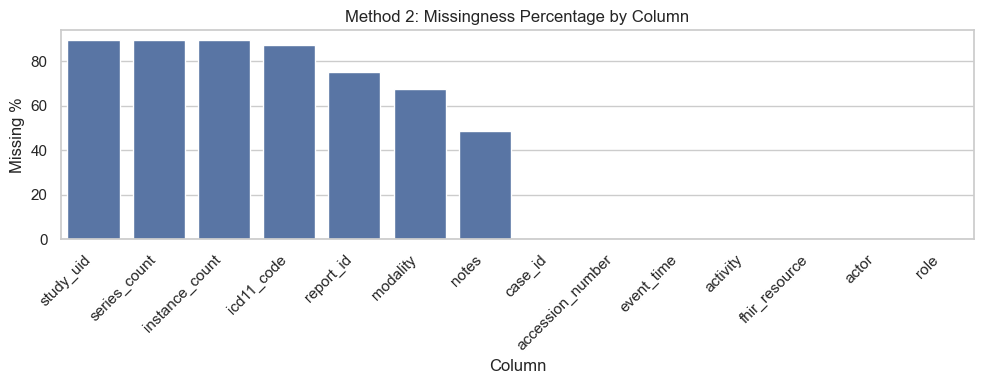

No placeholder patterns detected among configured placeholder tokens.


In [15]:
# Part 3 + Part 4 (Method 1 chosen run)

method_selection_df = pd.DataFrame([
    {
        'Method': 'Method 2: Completeness - Missing Values',
        'DQ Dimension': 'Completeness',
        'Primary Facets': 'Data, Source, System',
        'Relevant RQ(s)': 'RQ1, RQ2, RQ3',
        'Why chosen': 'Baseline check before any downstream analysis',
        'Expected findings': 'High missingness in optional metadata fields'
    },
    {
        'Method': 'Method 6: Representativity - Comprehensive',
        'DQ Dimension': 'Representativity',
        'Primary Facets': 'Data, Task, Human',
        'Relevant RQ(s)': 'RQ1, RQ3',
        'Why chosen': 'Checks whether urgency and temporal coverage are balanced',
        'Expected findings': 'Skew toward urgent/daytime cases'
    },
    {
        'Method': 'Method 8: Critical Communication Conformance',
        'DQ Dimension': 'Timeliness / Conformance',
        'Primary Facets': 'Task, System, Human',
        'Relevant RQ(s)': 'RQ2',
        'Why chosen': 'Directly tests safety-critical communication timing',
        'Expected findings': 'Most critical cases pass, but some deviations exist'
    },
    {
        'Method': 'Method 10: Turnaround Time + Batch Logging',
        'DQ Dimension': 'Timeliness + Credibility',
        'Primary Facets': 'Data, System, Task',
        'Relevant RQ(s)': 'RQ1',
        'Why chosen': 'Connects bottleneck metrics to timestamp reliability',
        'Expected findings': 'Batch logging inflates confidence in raw TAT values'
    },
    {
        'Method': 'Method 11: Workload Distribution',
        'DQ Dimension': 'Representativity / Human workload',
        'Primary Facets': 'Human, Task, System',
        'Relevant RQ(s)': 'RQ1, RQ3',
        'Why chosen': 'Reveals concentration patterns across actors/roles',
        'Expected findings': 'Uneven workload concentration by role/actor'
    },
])

print('=== Part 3: Selected Methods and Justification Table ===')
display(method_selection_df)

results_2 = method_2_completeness_missing_values(df)
print('\n=== Method 2: Completeness - Missing Values ===')

missing_counts_s = pd.Series(results_2['missing_counts']).sort_values(ascending=False)
missing_table = pd.DataFrame({
    'missing_count': missing_counts_s,
    'missing_pct': (missing_counts_s / len(df) * 100).round(2),
})
display(missing_table[missing_table['missing_count'] > 0])

plt.figure(figsize=(10, 4))
plot_data = missing_table.reset_index().rename(columns={'index': 'column'})
sns.barplot(data=plot_data, x='column', y='missing_pct', color='#4C72B0')
plt.title('Method 2: Missingness Percentage by Column')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

if results_2['potential_placeholders']:
    print('Potential placeholder values found:', results_2['potential_placeholders'])
else:
    print('No placeholder patterns detected among configured placeholder tokens.')


=== Method 6: Representativity - Comprehensive ===
Urgency distribution (case-level):


,stat_urgent_cases,routine_cases,unspecified,total_cases
0,15,2,0,17


Shift distribution (case-level):


,case_count
Night,6
Day,11
Evening,0


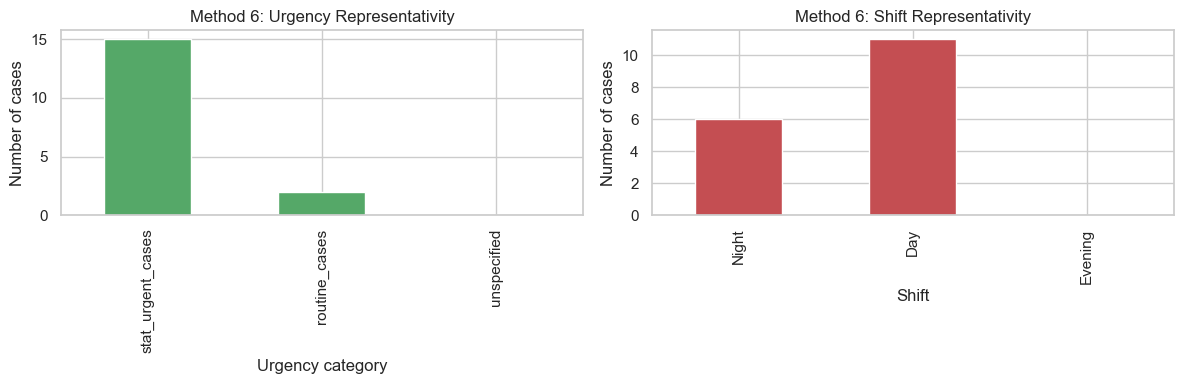

In [16]:
results_6 = method_6_representativity_comprehensive(df)
print('=== Method 6: Representativity - Comprehensive ===')

urgency = results_6.get('urgency_distribution', {})
shift = results_6.get('temporal_distribution', {}).get('cases_by_shift', {})

urgency_df = pd.DataFrame([urgency]) if urgency else pd.DataFrame()
shift_s = pd.Series(shift).reindex(['Night', 'Day', 'Evening']).fillna(0).astype(int)

print('Urgency distribution (case-level):')
display(urgency_df)
print('Shift distribution (case-level):')
display(shift_s.rename('case_count').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not urgency_df.empty:
    urgency_plot = urgency_df.T.drop(index=['total_cases'], errors='ignore')
    urgency_plot.columns = ['case_count']
    urgency_plot.plot(kind='bar', ax=axes[0], color='#55A868', legend=False)
    axes[0].set_title('Method 6: Urgency Representativity')
    axes[0].set_xlabel('Urgency category')
    axes[0].set_ylabel('Number of cases')
else:
    axes[0].text(0.5, 0.5, 'No urgency data available', ha='center', va='center')
    axes[0].set_axis_off()

shift_s.plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('Method 6: Shift Representativity')
axes[1].set_xlabel('Shift')
axes[1].set_ylabel('Number of cases')

plt.tight_layout()
plt.show()


=== Method 8: Critical Finding Communication Conformance (15 min threshold) ===


,case_id,c4_passed,c4_detail
0,CXR-001,True,Not a critical case
1,CXR-002,True,Not a critical case
2,CXR-003,True,Not a critical case
3,CXR-004,False,Critical case missing Critical communication e...
4,CXR-005,True,Not a critical case
5,CXR-006,True,Not a critical case
6,CXR-007,True,Not a critical case
7,CXR-008,True,Not a critical case
8,CXR-009,True,Not a critical case
9,CXR-010,True,Communication gap: 7.0 minutes (threshold: 15)


Pass/fail summary:


,case_count
c4_passed,
Pass,16
Fail,1


Failed cases:


,case_id,c4_passed,c4_detail
3,CXR-004,False,Critical case missing Critical communication e...


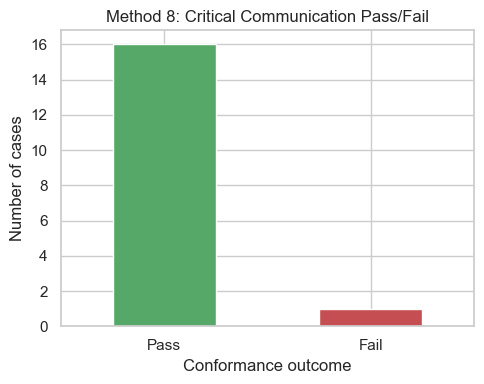

In [17]:
results_8 = method_8_conformance_critical_communication(df, threshold_minutes=15)
print('=== Method 8: Critical Finding Communication Conformance (15 min threshold) ===')

display(results_8.sort_values('case_id'))

summary_8 = results_8['c4_passed'].value_counts().rename(index={True: 'Pass', False: 'Fail'})
summary_8_df = summary_8.rename('case_count').to_frame()
print('Pass/fail summary:')
display(summary_8_df)

failed_critical_cases = results_8[~results_8['c4_passed']]
if failed_critical_cases.empty:
    print('No failed critical communication cases detected.')
else:
    print('Failed cases:')
    display(failed_critical_cases)

plt.figure(figsize=(5, 4))
summary_8.plot(kind='bar', color=['#55A868', '#C44E52'])
plt.title('Method 8: Critical Communication Pass/Fail')
plt.xlabel('Conformance outcome')
plt.ylabel('Number of cases')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


=== Method 10: Turnaround Time with Batch Logging Detection ===


,metric,raw_minutes,clean_minutes
0,"Order to acquisition (mean, min)",30.38,36.8
1,"Upload to report (mean, min)",111.40,156.8
2,"Total TAT (mean, min)",147.93,198.5


,total_cases,batch_logging_suspected_count,batch_logging_percentage
0,17,6,35.29


Batch-logging suspected cases:


,case_id,batch_warnings,total_tat_minutes
1,CXR-002,Duplicate timestamps: 2 events,113.0
10,CXR-011,Duplicate timestamps: 8 events; Unrealistic or...,1.0
11,CXR-012,Duplicate timestamps: 2 events,106.0
12,CXR-013,Duplicate timestamps: 13 events; Unrealistic o...,1.0
14,CXR-015,Unrealistic order-to-acquisition: 2.0 min,NaN
15,CXR-016,Duplicate timestamps: 2 events,13.0


,case_id,order_to_acquisition_minutes,upload_to_report_minutes,total_tat_minutes,batch_logging_suspected
10,CXR-011,0.0,1.0,1.0,True
12,CXR-013,0.0,1.0,1.0,True
15,CXR-016,5.0,5.0,13.0,True
9,CXR-010,20.0,26.0,51.0,False
8,CXR-009,28.0,29.0,58.0,False
7,CXR-008,24.0,39.0,68.0,False
5,CXR-006,32.0,33.0,71.0,False
6,CXR-007,30.0,35.0,71.0,False
4,CXR-005,37.0,39.0,81.0,False
0,CXR-001,60.0,40.0,105.0,False


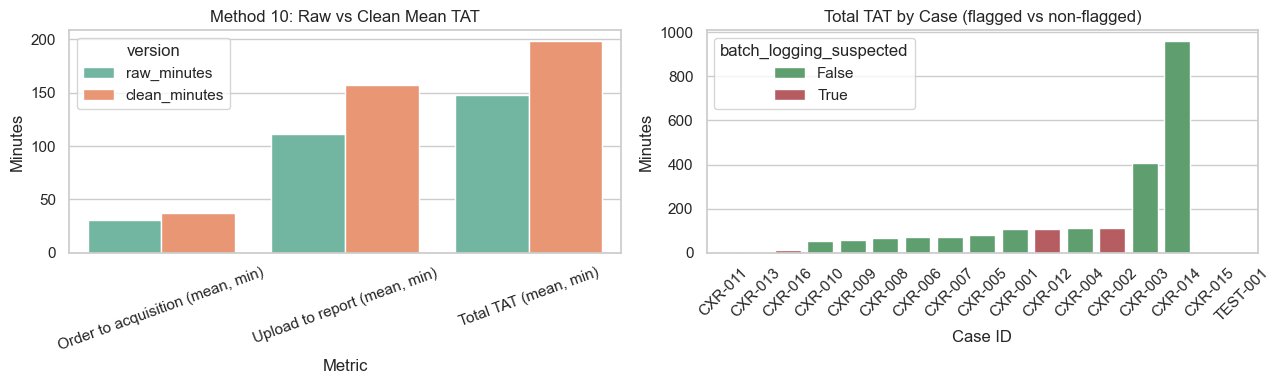

In [18]:
results_10 = method_10_turnaround_times(df)
tat_df = results_10['detailed_data'].copy()

print('=== Method 10: Turnaround Time with Batch Logging Detection ===')

summary_10_df = pd.DataFrame([
    {
        'metric': 'Order to acquisition (mean, min)',
        'raw_minutes': round(results_10['mean_order_to_acquisition'], 2) if results_10['mean_order_to_acquisition'] is not None else np.nan,
        'clean_minutes': round(results_10['mean_order_to_acquisition_clean'], 2) if results_10['mean_order_to_acquisition_clean'] is not None else np.nan,
    },
    {
        'metric': 'Upload to report (mean, min)',
        'raw_minutes': round(results_10['mean_upload_to_report'], 2) if results_10['mean_upload_to_report'] is not None else np.nan,
        'clean_minutes': round(results_10['mean_upload_to_report_clean'], 2) if results_10['mean_upload_to_report_clean'] is not None else np.nan,
    },
    {
        'metric': 'Total TAT (mean, min)',
        'raw_minutes': round(results_10['mean_total_tat'], 2) if results_10['mean_total_tat'] is not None else np.nan,
        'clean_minutes': round(results_10['mean_total_tat_clean'], 2) if results_10['mean_total_tat_clean'] is not None else np.nan,
    },
])

batch_summary_df = pd.DataFrame([
    {
        'total_cases': results_10['total_cases'],
        'batch_logging_suspected_count': results_10['batch_logging_suspected_count'],
        'batch_logging_percentage': round(results_10['batch_logging_percentage'], 2),
    }
])

display(summary_10_df)
display(batch_summary_df)

flagged_cases_df = tat_df[tat_df['batch_logging_suspected']][['case_id', 'batch_warnings', 'total_tat_minutes']]
print('Batch-logging suspected cases:')
display(flagged_cases_df if not flagged_cases_df.empty else pd.DataFrame({'note': ['No cases flagged']}))

display(tat_df[['case_id', 'order_to_acquisition_minutes', 'upload_to_report_minutes', 'total_tat_minutes', 'batch_logging_suspected']].sort_values('total_tat_minutes'))

plot_df = summary_10_df.melt(id_vars='metric', value_vars=['raw_minutes', 'clean_minutes'], var_name='version', value_name='minutes')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=plot_df, x='metric', y='minutes', hue='version', ax=axes[0], palette='Set2')
axes[0].set_title('Method 10: Raw vs Clean Mean TAT')
axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Minutes')
axes[0].tick_params(axis='x', rotation=20)

tat_plot_df = tat_df[['case_id', 'total_tat_minutes', 'batch_logging_suspected']].sort_values('total_tat_minutes')
sns.barplot(data=tat_plot_df, x='case_id', y='total_tat_minutes', hue='batch_logging_suspected', ax=axes[1], palette={False: '#55A868', True: '#C44E52'})
axes[1].set_title('Total TAT by Case (flagged vs non-flagged)')
axes[1].set_xlabel('Case ID')
axes[1].set_ylabel('Minutes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


=== Method 11: Workload Distribution Analysis ===


,unique_cases
system,17
clinician,16
radiographer,16
senior,15
resident,4


,event_count
radiographer,64
system,31
senior,31
clinician,17
resident,7


,unique_cases
RIS System,16
Dr. Sørensen,10
Tech. Hansen,7
Dr. Christensen,5
Tech. Olsen,5
Dr. Andersen,4
Dr. Jensen,4
Dr. Nielsen,4
Tech. Larsen,4
Dr. Kumar,3


Potential workload outliers detected:


,unique_cases
RIS System,16


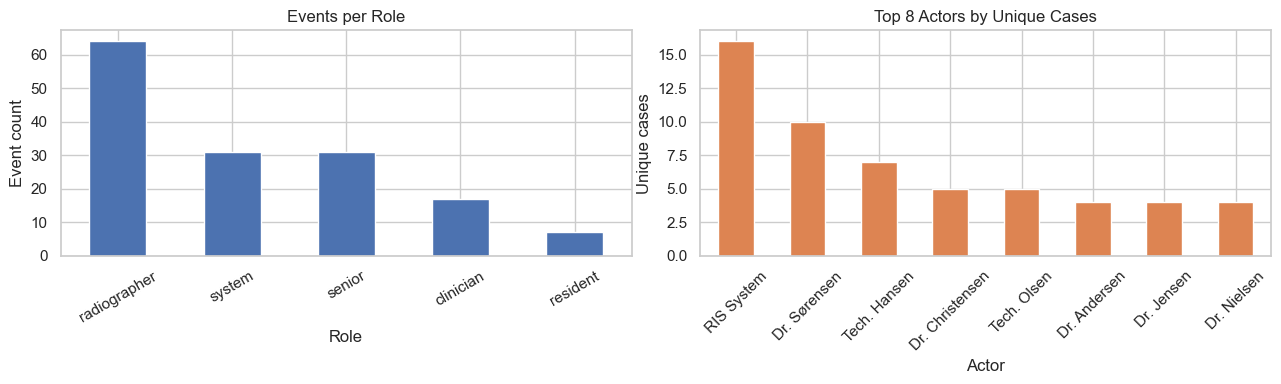

In [19]:
results_11 = method_11_workload_distribution(df)
print('=== Method 11: Workload Distribution Analysis ===')

cases_per_role_s = pd.Series(results_11['cases_per_role']).sort_values(ascending=False)
events_per_role_s = pd.Series(results_11['events_per_role']).sort_values(ascending=False)
cases_per_actor_s = pd.Series(results_11['cases_per_actor']).sort_values(ascending=False)

display(cases_per_role_s.rename('unique_cases').to_frame())
display(events_per_role_s.rename('event_count').to_frame())
display(cases_per_actor_s.rename('unique_cases').to_frame().head(10))

if results_11.get('workload_outliers'):
    print('Potential workload outliers detected:')
    display(pd.Series(results_11['workload_outliers']).rename('unique_cases').to_frame())
else:
    print('No workload outliers detected by the configured threshold.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

events_per_role_s.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Events per Role')
axes[0].set_xlabel('Role')
axes[0].set_ylabel('Event count')
axes[0].tick_params(axis='x', rotation=30)

top_actors = cases_per_actor_s.head(8)
top_actors.plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Top 8 Actors by Unique Cases')
axes[1].set_xlabel('Actor')
axes[1].set_ylabel('Unique cases')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Part 5: Manual Exploration — Propose Your Own DQ Dimension

Based on your exploration, identify a DQ concern NOT adequately covered by the provided methods.

**Task**:
1. Manually explore the data to identify a quality issue
2. Name and define a DQ dimension that captures this issue
3. Map it to the Five Facets framework
4. Write code to demonstrate the issue
5. Propose an assessment approach

=== Exploration for custom DQ dimension: Operational authenticity ===
Case profile (selected columns):


,event_count,duration_minutes,case_id_format_ok,has_training_test_note,uses_admin_actor,suspicion_score
case_id,,,,,,
CXR-001,9,105.0,True,False,False,0
CXR-002,9,113.0,True,False,False,0
CXR-003,11,408.0,True,False,False,0
CXR-004,10,111.0,True,False,False,0
CXR-005,9,81.0,True,False,False,0
CXR-006,8,71.0,True,False,False,0
CXR-007,10,71.0,True,False,False,0
CXR-008,8,68.0,True,False,False,0
CXR-009,9,62.0,True,False,False,0


Flagged suspect cases based on exploration signals:


,event_count,duration_minutes,case_id_format_ok,has_training_test_note,uses_admin_actor,suspicion_score
case_id,,,,,,
TEST-001,1,0.0,False,True,True,4


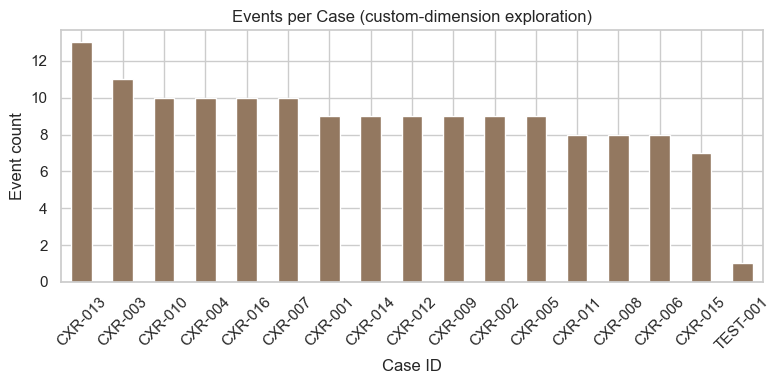

In [20]:
# Part 5 exploration: identify a quality issue not fully covered by provided methods
# Proposed concern: Operational authenticity (production-relevance validity)
# Motivation: Event logs may include test/training/non-clinical traces that can bias RQ conclusions.

case_profile = df.groupby('case_id').agg(
    event_count=('activity', 'size'),
    first_time=('event_time', 'min'),
    last_time=('event_time', 'max'),
    unique_actors=('actor', 'nunique'),
)
case_profile['duration_minutes'] = (case_profile['last_time'] - case_profile['first_time']).dt.total_seconds() / 60

case_profile['case_id_format_ok'] = case_profile.index.to_series().str.match(r'^CXR-\d{3}$')
case_profile['has_training_test_note'] = df.groupby('case_id')['notes'].apply(
    lambda s: s.astype(str).str.contains(r'training|test|do not process', case=False, na=False).any()
)
case_profile['uses_admin_actor'] = df.groupby('case_id')['actor'].apply(lambda s: s.eq('Admin User').any())

case_profile['suspicion_score'] = (
    (~case_profile['case_id_format_ok']).astype(int)
    + case_profile['has_training_test_note'].astype(int)
    + case_profile['uses_admin_actor'].astype(int)
    + (case_profile['event_count'] < 3).astype(int)
)

suspect_cases = case_profile[case_profile['suspicion_score'] > 0].sort_values('suspicion_score', ascending=False)

print('=== Exploration for custom DQ dimension: Operational authenticity ===')
print('Case profile (selected columns):')
display(case_profile[['event_count', 'duration_minutes', 'case_id_format_ok', 'has_training_test_note', 'uses_admin_actor', 'suspicion_score']])

print('Flagged suspect cases based on exploration signals:')
display(suspect_cases[['event_count', 'duration_minutes', 'case_id_format_ok', 'has_training_test_note', 'uses_admin_actor', 'suspicion_score']])

plt.figure(figsize=(8, 4))
plot_case_counts = case_profile.sort_values('event_count', ascending=False)['event_count']
plot_case_counts.plot(kind='bar', color='#937860')
plt.title('Events per Case (custom-dimension exploration)')
plt.xlabel('Case ID')
plt.ylabel('Event count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 5.1 Your Proposed DQ Dimension

**→ Reflection Question 4** (answer in your main report):  
Expand on your proposed DQ dimension. 
- Define your dimension.
- *What specific pattern or issue in the data motivated this dimension? Reference your exploration code above. Provide concrete examples.*
- *Which research question(s) would be affected by this quality issue? How?*
- Map the dimension relevancy in across the five facets

**Facet Mapping**:

| Facet | Involvement (++, +, -) | Justification |
|-------|------------------------|---------------|
| Data | | |
| Source | | |
| System | | |
| Task | | |
| Human | | |


In [21]:
def my_custom_dq_method(df: pd.DataFrame) -> Dict[str, any]:
    """
    Assess operational authenticity (production-relevance validity).

    Goal:
    Identify case traces that are likely test/training/non-production records
    or otherwise not representative of real clinical workflow data.
    """
    rows = []

    for case_id, case_df in df.groupby('case_id'):
        reasons = []

        if not re.match(r'^CXR-\d{3}$', str(case_id)):
            reasons.append('Unexpected case_id format')

        if case_df['notes'].astype(str).str.contains(r'training|test|do not process', case=False, na=False).any():
            reasons.append('Training/test markers in notes')

        if case_df['actor'].eq('Admin User').any():
            reasons.append('Administrative/test actor involvement')

        if len(case_df) < 3:
            reasons.append('Extremely short trace (low operational realism)')

        score = len(reasons)
        if score >= 3:
            risk_level = 'high'
        elif score >= 1:
            risk_level = 'medium'
        else:
            risk_level = 'low'

        rows.append({
            'case_id': case_id,
            'risk_level': risk_level,
            'risk_score': score,
            'reasons': '; '.join(reasons) if reasons else 'None',
            'event_count': len(case_df),
        })

    case_flags = pd.DataFrame(rows).sort_values(['risk_score', 'case_id'], ascending=[False, True])
    flagged = case_flags[case_flags['risk_level'].isin(['high', 'medium'])].copy()

    summary_metrics = {
        'total_cases': int(len(case_flags)),
        'flagged_cases': int(len(flagged)),
        'flagged_case_rate_pct': round(100 * len(flagged) / len(case_flags), 2) if len(case_flags) > 0 else 0.0,
        'high_risk_cases': int((case_flags['risk_level'] == 'high').sum()),
    }

    return {
        'case_flags': case_flags,
        'flagged_cases': flagged,
        'summary_metrics': summary_metrics,
    }

# Run custom method
custom_results = my_custom_dq_method(df)
print('=== My Custom DQ Assessment: Operational Authenticity ===')
display(pd.DataFrame([custom_results['summary_metrics']]))
display(custom_results['case_flags'])

if not custom_results['flagged_cases'].empty:
    print('Flagged cases for review:')
    display(custom_results['flagged_cases'])

facet_mapping_df = pd.DataFrame([
    {'Facet': 'Data', 'Involvement': '++', 'Justification': 'Case identifiers and notes fields carry the direct test/training contamination signal.'},
    {'Facet': 'Source', 'Involvement': '++', 'Justification': 'Source process determines whether non-production records enter the analytic log.'},
    {'Facet': 'System', 'Involvement': '+', 'Justification': 'System/environment boundaries (test vs production) are not explicitly separated in logs.'},
    {'Facet': 'Task', 'Involvement': '+', 'Justification': 'Operational KPIs and triage models are biased if non-clinical traces are included.'},
    {'Facet': 'Human', 'Involvement': '+', 'Justification': 'Human actors create or leave behind training/test traces during maintenance or onboarding.'},
])

print('Facet mapping for the proposed custom dimension:')
display(facet_mapping_df)


=== My Custom DQ Assessment: Operational Authenticity ===


,total_cases,flagged_cases,flagged_case_rate_pct,high_risk_cases
0,17,1,5.88,1


,case_id,risk_level,risk_score,reasons,event_count
16,TEST-001,high,4,Unexpected case_id format; Training/test marke...,1
0,CXR-001,low,0,None,9
1,CXR-002,low,0,None,9
2,CXR-003,low,0,None,11
3,CXR-004,low,0,None,10
4,CXR-005,low,0,None,9
5,CXR-006,low,0,None,8
6,CXR-007,low,0,None,10
7,CXR-008,low,0,None,8
8,CXR-009,low,0,None,9


Flagged cases for review:


,case_id,risk_level,risk_score,reasons,event_count
16,TEST-001,high,4,Unexpected case_id format; Training/test marke...,1


Facet mapping for the proposed custom dimension:


,Facet,Involvement,Justification
0,Data,++,Case identifiers and notes fields carry the di...
1,Source,++,Source process determines whether non-producti...
2,System,+,System/environment boundaries (test vs product...
3,Task,+,Operational KPIs and triage models are biased ...
4,Human,+,Human actors create or leave behind training/t...


 ## Part 6: Per-Facet Data Quality Synthesis

**→ Reflection Question 5** (answer in your main report):  
For each of the five data quality facets, interpret the results you got when running selected methods and assess the quality of the dataset. You can use these questions as guidance,
- What did your methods reveal about data quality at \[a facet\] level?
- What are the main data quality issues?
- What could be the consequences in regard to the RQs?

**Then discuss:**
a) Which facet was most challenging to assess with the available methods? Why?  
b) How else could these data quality facets be assessed?

In [22]:
# Part 6 evidence scaffold (not full reflection answers)
facet_synthesis_input = pd.DataFrame([
    {
        'Facet': 'Data',
        'Evidence from notebook outputs': 'M2 missingness profile; M10 timestamp-sensitive TAT differences; custom method flags',
        'Primary RQ impact': 'RQ1, RQ2, RQ3',
    },
    {
        'Facet': 'Source',
        'Evidence from notebook outputs': 'M2 context-field sparsity and custom method source contamination signals',
        'Primary RQ impact': 'RQ1, RQ3',
    },
    {
        'Facet': 'System',
        'Evidence from notebook outputs': 'M8 communication conformance failures; M10 batch logging warnings',
        'Primary RQ impact': 'RQ1, RQ2',
    },
    {
        'Facet': 'Task',
        'Evidence from notebook outputs': 'M6 urgency/shift skew; M8 timing threshold performance',
        'Primary RQ impact': 'RQ1, RQ2, RQ3',
    },
    {
        'Facet': 'Human',
        'Evidence from notebook outputs': 'M11 workload concentration by actor/role',
        'Primary RQ impact': 'RQ1, RQ3',
    },
])

print('=== Part 6 evidence scaffold table ===')
display(facet_synthesis_input)


=== Part 6 evidence scaffold table ===


,Facet,Evidence from notebook outputs,Primary RQ impact
0,Data,M2 missingness profile; M10 timestamp-sensitiv...,"RQ1, RQ2, RQ3"
1,Source,M2 context-field sparsity and custom method so...,"RQ1, RQ3"
2,System,M8 communication conformance failures; M10 bat...,"RQ1, RQ2"
3,Task,M6 urgency/shift skew; M8 timing threshold per...,"RQ1, RQ2, RQ3"
4,Human,M11 workload concentration by actor/role,"RQ1, RQ3"


## Part 7: Invisible Work — Comparing Log to Workflow Diagram

The assignment document includes a workflow diagram showing the actual radiology process with informal communication (orange dashed lines).

**Task**: Identify gaps between the event log and the workflow diagram.

In [23]:
print('=== Activities in Event Log ===')
activities_df = pd.DataFrame({'logged_activity': sorted(df['activity'].dropna().unique())})
display(activities_df)

print('Total unique logged activities:', len(activities_df))

invisible_work_df = pd.DataFrame([
    {
        'Activity from Diagram': 'Radiologist-to-radiologist consultation',
        'Why not logged?': 'Mostly verbal/ad-hoc communication outside structured event capture',
        'Which facet explains this?': 'Human, Task',
        'Consequences': 'Collaboration work is invisible in process mining and workload interpretation',
        'How could it be captured?': 'Optional lightweight consult event with minimal metadata',
    },
    {
        'Activity from Diagram': 'Clarification call to ordering clinician',
        'Why not logged?': 'Often occurs by phone and is not integrated with RIS/PACS logging',
        'Which facet explains this?': 'System, Source',
        'Consequences': 'Delay attribution and communication pathways are underrepresented',
        'How could it be captured?': 'Linked communication event type with reason code',
    },
    {
        'Activity from Diagram': 'Informal reprioritisation and handoff',
        'Why not logged?': 'Queue negotiations are local and socially coordinated',
        'Which facet explains this?': 'Task, Human',
        'Consequences': 'Bottleneck and fairness analyses can miss real prioritisation logic',
        'How could it be captured?': 'Priority-change event with actor and rationale',
    },
    {
        'Activity from Diagram': 'Cross-team coordination around patient readiness',
        'Why not logged?': 'Preparation interactions happen across systems and departments',
        'Which facet explains this?': 'Source, System, Task',
        'Consequences': 'Waiting-time drivers are hidden, distorting turnaround interpretation',
        'How could it be captured?': 'Inter-department status event linked to case timeline',
    },
])

print('\n=== Invisible Work Analysis Table (for Part 7 / Reflection 6) ===')
display(invisible_work_df)


=== Activities in Event Log ===


,logged_activity
0,Case selected
1,Critical communication
2,Image acquisition end
3,Image acquisition start
4,Images uploaded to PACS
5,Order accepted
6,Order placed
7,Patient selected from worklist
8,Preliminary report created
9,Report distributed


Total unique logged activities: 12

=== Invisible Work Analysis Table (for Part 7 / Reflection 6) ===


,Activity from Diagram,Why not logged?,Which facet explains this?,Consequences,How could it be captured?
0,Radiologist-to-radiologist consultation,Mostly verbal/ad-hoc communication outside str...,"Human, Task",Collaboration work is invisible in process min...,Optional lightweight consult event with minima...
1,Clarification call to ordering clinician,Often occurs by phone and is not integrated wi...,"System, Source",Delay attribution and communication pathways a...,Linked communication event type with reason code
2,Informal reprioritisation and handoff,Queue negotiations are local and socially coor...,"Task, Human",Bottleneck and fairness analyses can miss real...,Priority-change event with actor and rationale
3,Cross-team coordination around patient readiness,Preparation interactions happen across systems...,"Source, System, Task","Waiting-time drivers are hidden, distorting tu...",Inter-department status event linked to case t...


### 7.1 Invisible Work Analysis

Complete the table with at least **3 activities** from the workflow diagram that do NOT appear in the log:

| Activity from Diagram | Why not logged? | Which facet explains this? | Consequences | How could it be captured? |
|----------------------|-----------------|---------------------------|--------------|---------------------------|
| | | | | |
| | | | | |
| | | | | |

---

**→ Reflection Question 6** (answer in your main report):  
a) For each activity, explain why it might not be logged (technical, social, economic reasons)
b) Reflect on how a process model built \emph{only} from the event log would fail to capture these activities. What are the potential consequences for system design, in regard to each of the research questions?
c) How does your Part I experience (interview vs. observation) parallel the gap between event log and workflow diagram?
d) What does the gap between logged data and actual practice tell us about building healthcare IT systems from ``data-driven'' approaches alone?
e) Propose one concrete change to the logging system that would capture currently invisible work. Draw on concepts from Chapter 9 (Formal and informal information systems) to discuss trade-offs: Why is complete logging difficult or even unwelcome in real-world settings? How could negative impacts be mitigated?